# EDA

## Subreddit-1: learnprogramming

### Part-1: Data Overview

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

In [25]:
DATA_DIR = '/Users/yangshuting/Desktop/UChicago/courses/spring_2026/MACS_30200_Research_Design/final_proposal/data/learnprogramming/'
POSTS_PATH    = DATA_DIR + 'r_learnprogramming_posts.jsonl'
COMMENTS_PATH = DATA_DIR + 'r_learnprogramming_comments.jsonl'
OBS_END = pd.Timestamp('2026-01-01', tz='UTC')

In [26]:
# load posts - keep only needed columns
POSTS_COLS = ['author', 'created_utc', 'id', 'title', 'selftext', 'score', 'num_comments']

posts = []
with open(POSTS_PATH) as f:
    for line in f:
        d = json.loads(line)
        posts.append({k: d.get(k) for k in POSTS_COLS})

posts_df = pd.DataFrame(posts)
posts_df.shape

(640028, 7)

In [27]:
# load comments - keep only needed columns
COMMENTS_COLS = ['author', 'created_utc', 'id', 'body', 'score', 'parent_id', 'link_id']

comments = []
with open(COMMENTS_PATH) as f:
    for line in f:
        d = json.loads(line)
        comments.append({k: d.get(k) for k in COMMENTS_COLS})

comments_df = pd.DataFrame(comments)
comments_df.shape

(4464776, 7)

In [28]:
# get an overview of posts
posts_df.head()

,author,created_utc,id,title,selftext,score,num_comments
0,6553321,1253766972,9njl7,Welcome everyone.,In honor of http://www.reddit.com/r/programmin...,12,11
1,6553321,1253772944,9nkb7,Keywords to save you a Google,Trying to collect keywords that may be thrown ...,8,11
2,6553321,1253775523,9nkok,C how to program,,11,13
3,lolinyerface,1253795135,9nn5f,Interested in learning Python?,,19,14
4,Dman003,1253951269,9o9g0,Does using code snippets when programming help?,,8,5


In [29]:
# get an overview of comments
comments_df.head()

,author,created_utc,id,body,score,parent_id,link_id
0,6553321,1253767158,c0divrv,For starters we can have basic learn <language...,1,t3_9njl7,t3_9njl7
1,sutcivni,1253769598,c0dix96,The question is how are we going to distinguis...,2,t1_c0divrv,t3_9njl7
2,6553321,1253772781,c0diyv9,I don't think there is a real need to but we'l...,1,t1_c0dix96,t3_9njl7
3,WebDevWannaBe,1253774613,c0dizo3,my repost from the other thread: (just let me ...,2,t3_9njl7,t3_9njl7
4,6553321,1253775120,c0dizwp,Compiler: A tool that takes a program written ...,7,t3_9nkb7,t3_9nkb7


In [30]:
# check data types
posts_df.dtypes

author          object
created_utc      int64
id              object
title           object
selftext        object
score            int64
num_comments     int64
dtype: object

### Part-2: Data Cleaning

#### 2.1 Missing values

In [31]:
# check missing values
null_posts    = posts_df.isnull().sum()
null_comments = comments_df.isnull().sum()
print('=== Posts ===')
print(null_posts)
print('\n=== Comments ===')
print(null_comments)

=== Posts ===
author          0
created_utc     0
id              0
title           0
selftext        0
score           0
num_comments    0
dtype: int64

=== Comments ===
author         0
created_utc    0
id             0
body           0
score          0
parent_id      0
link_id        0
dtype: int64


In [32]:
# drop columns that have at least 30% missing values
posts_df.drop(columns=posts_df.columns[null_posts > len(posts_df) * 0.3], inplace=True)
comments_df.drop(columns=comments_df.columns[null_comments > len(comments_df) * 0.3], inplace=True)

# check remaining columns
print('posts columns:', posts_df.columns.tolist())
print('comments columns:', comments_df.columns.tolist())

posts columns: ['author', 'created_utc', 'id', 'title', 'selftext', 'score', 'num_comments']
comments columns: ['author', 'created_utc', 'id', 'body', 'score', 'parent_id', 'link_id']


#### 2.2 Remove duplicates

In [33]:
# check duplicate content: same user posting identical text
# posts: same author + same title; 
# comments: same author + same body
dup_posts    = posts_df.duplicated(subset=['author', 'title'], keep=False).sum()
dup_comments = comments_df.duplicated(subset=['author', 'body'], keep=False).sum()

print(f'duplicate posts (same author + title):   {dup_posts:,}')
print(f'duplicate comments (same author + body): {dup_comments:,}')

duplicate posts (same author + title):   18,233
duplicate comments (same author + body): 346,508


In [34]:
# drop duplicates, keep first occurrence
posts_df    = posts_df.drop_duplicates(subset=['author', 'title'], keep='first').reset_index(drop=True)
comments_df = comments_df.drop_duplicates(subset=['author', 'body'],  keep='first').reset_index(drop=True)

n_posts_after_dedup    = len(posts_df)
n_comments_after_dedup = len(comments_df)
print(f'posts after dedup:    {n_posts_after_dedup:,}')
print(f'comments after dedup: {n_comments_after_dedup:,}')

posts after dedup:    627,004
comments after dedup: 4,133,442


#### 2.3 Remove user-deleted accounts

In [35]:
# check [deleted] author proportion
print('=== Posts ===')
print(f'total: {len(posts_df):,}')
print(f'[deleted]: {(posts_df["author"] == "[deleted]").sum():,}  ({(posts_df["author"] == "[deleted]").mean()*100:.1f}%)')
print(f'[removed]: {(posts_df["author"] == "[removed]").sum():,}')

print('\n=== Comments ===')
print(f'total: {len(comments_df):,}')
print(f'[deleted]: {(comments_df["author"] == "[deleted]").sum():,}  ({(comments_df["author"] == "[deleted]").mean()*100:.1f}%)')
print(f'[removed]: {(comments_df["author"] == "[removed]").sum():,}')

=== Posts ===
total: 627,004
[deleted]: 109,566  (17.5%)
[removed]: 0

=== Comments ===
total: 4,133,442
[deleted]: 107,076  (2.6%)
[removed]: 0


Each Reddit record has two distinct fields: `author` (who posted it) and `selftext`/`body` (what they wrote). When a user deletes their own account, the `author` field is replaced with "[deleted]", which is what 2.3 filters on. When a moderator removes a post, only the post content (`selftext`) is replaced with "[removed]" while the `author` field keeps the original username. This is why `[removed]` never appears in the `author` column here, but does appear in `selftext` in 2.4 (the mod-removed post bodies, not deleted accounts).

In [36]:
# remove user-deleted accounts
posts_df    = posts_df[~posts_df['author'].isin(['[deleted]', '[removed]'])].reset_index(drop=True)
comments_df = comments_df[~comments_df['author'].isin(['[deleted]', '[removed]'])].reset_index(drop=True)

n_posts_after_deleted    = len(posts_df)
n_comments_after_deleted = len(comments_df)
print(f'posts after filtering:    {n_posts_after_deleted:,}')
print(f'comments after filtering: {n_comments_after_deleted:,}')

posts after filtering:    517,438
comments after filtering: 4,026,366


#### 2.4 Remove mod-deleted post and comment content

In [37]:
# check [deleted] / [removed] text in content fields
print(f'posts with [deleted] selftext:  {(posts_df["selftext"] == "[deleted]").sum():,}')
print(f'posts with [removed] selftext:  {(posts_df["selftext"] == "[removed]").sum():,}')
print(f'comments with [deleted] body:   {(comments_df["body"] == "[deleted]").sum():,}')
print(f'comments with [removed] body:   {(comments_df["body"] == "[removed]").sum():,}')

posts with [deleted] selftext:  1
posts with [removed] selftext:  48,614
comments with [deleted] body:   9
comments with [removed] body:   1


In [38]:
# replace [deleted] / [removed] text with NaN
posts_df['selftext'] = posts_df['selftext'].replace(['[deleted]', '[removed]'], None)
comments_df['body']  = comments_df['body'].replace(['[deleted]', '[removed]'], None)

# re-check missing after replacing
print(f'selftext missing after cleaning: {posts_df["selftext"].isnull().sum():,}')
print(f'body missing after cleaning:     {comments_df["body"].isnull().sum():,}')

selftext missing after cleaning: 48,615
body missing after cleaning:     10


#### 2.5 Remove bots

In [39]:
# check top 30 most active commenters to identify bots
top_commenters = comments_df['author'].value_counts().head(30)
top_commenters

author
desrtfx                 37039
insertAlias             21699
dmazzoni                18610
g051051                 18559
nutrecht                18361
CodeTinkerer            17162
lurgi                   13749
Updatebjarni            13606
exoticmatter            13343
CreativeTechGuyGames    12589
rjcarr                  11584
captainAwesomePants     10530
Rhomboid                 9588
_Atomfinger_             9006
plastikmissile           8861
zifyoip                  8235
chaotic_thought          7783
AutoModerator            7524
denialerror              7314
michael0x2a              6812
jedwardsol               6028
149244179                6014
davedontmind             5995
aqua_regis               5945
raevnos                  5865
jesyspa                  5827
ValentineBlacker         5794
the_omega99              5557
POGtastic                5386
YuleTideCamel            5309
Name: count, dtype: int64

In [40]:
# define known bots and remove them
BOTS = [
    'AutoModerator', 'BotDefense', 'RepostSleuthBot', 'snapshillbot',
    'WikiTextBot', 'LinkifyBot', 'TweetPoster', 'imgurtranscriber',
    'MAGIC_EYE_BOT', 'RemindMeBot', 'haikusbot', 'converter-bot'
]

posts_df    = posts_df[~posts_df['author'].isin(BOTS)].reset_index(drop=True)
comments_df = comments_df[~comments_df['author'].isin(BOTS)].reset_index(drop=True)

n_posts_after_bots    = len(posts_df)
n_comments_after_bots = len(comments_df)
print(f'posts after bot removal:    {n_posts_after_bots:,}')
print(f'comments after bot removal: {n_comments_after_bots:,}')

posts after bot removal:    517,079
comments after bot removal: 4,017,272


#### 2.6 User activity records and low-activity filtering

In [41]:
# convert timestamps
posts_df['created_utc']    = pd.to_datetime(posts_df['created_utc'], unit='s', utc=True)
comments_df['created_utc'] = pd.to_datetime(comments_df['created_utc'], unit='s', utc=True)

In [42]:
# each post/comment = one transaction (following BG/NBD convention)
activity = pd.concat([
    posts_df[['author', 'created_utc']],
    comments_df[['author', 'created_utc']]
], ignore_index=True).sort_values('created_utc').reset_index(drop=True)

print(f'total activity records: {len(activity):,}')

total activity records: 4,534,351


In [43]:
# compute per-user activity stats
user_stats = activity.groupby('author').agg(
    n_activity = ('created_utc', 'count'),
    first_post = ('created_utc', 'min'),
    last_post  = ('created_utc', 'max')
).reset_index()

print(f'total unique users: {len(user_stats):,}')
user_stats.head()

total unique users: 601,498


,author,n_activity,first_post,last_post
0,-------------------7,7,2017-11-30 20:27:45+00:00,2025-12-18 00:02:41+00:00
1,-------___---------,1,2019-06-11 04:15:15+00:00,2019-06-11 04:15:15+00:00
2,------Fire------,2,2025-01-09 22:54:06+00:00,2025-01-12 08:09:34+00:00
3,------_-_-_------,1,2020-06-13 08:30:55+00:00,2020-06-13 08:30:55+00:00
4,------what------,1,2021-03-17 02:16:19+00:00,2021-03-17 02:16:19+00:00


In [44]:
# compute the bottom 5% activity threshold (calculated per subreddit)
threshold = int(user_stats['n_activity'].quantile(0.05))
print(f'bottom 5% threshold: {threshold} activities')
print(f'users before filter: {len(user_stats):,}')

bottom 5% threshold: 1 activities
users before filter: 601,498


In [45]:
# drop users below the threshold
user_stats = user_stats[user_stats['n_activity'] >= threshold].reset_index(drop=True)
qualifying_users = set(user_stats['author'])

# filter activity, posts_df, comments_df to qualifying users only
activity    = activity[activity['author'].isin(qualifying_users)].reset_index(drop=True)
posts_df    = posts_df[posts_df['author'].isin(qualifying_users)].reset_index(drop=True)
comments_df = comments_df[comments_df['author'].isin(qualifying_users)].reset_index(drop=True)

print(f'qualifying users:   {len(user_stats):,}')
print(f'posts (final):      {len(posts_df):,}')
print(f'comments (final):   {len(comments_df):,}')

qualifying users:   601,498
posts (final):      517,079
comments (final):   4,017,272


#### 2.7 Summary

In [46]:
# cleaning steps summary
summary = pd.DataFrame({
    'Step': [
        'Raw posts',
        'Raw comments',
        'After removing duplicates (posts)',
        'After removing duplicates (comments)',
        'After removing [deleted] authors (posts)',
        'After removing [deleted] authors (comments)',
        'After removing bots (posts)',
        'After removing bots (comments)',
        'Final posts (qualifying users only)',
        'Final comments (qualifying users only)',
        'Qualifying users'
    ],
    'Count': [
        640028,
        4464776,
        n_posts_after_dedup,
        n_comments_after_dedup,
        n_posts_after_deleted,
        n_comments_after_deleted,
        n_posts_after_bots,
        n_comments_after_bots,
        len(posts_df),
        len(comments_df),
        len(user_stats)
    ]
})
summary

,Step,Count
0,Raw posts,640028
1,Raw comments,4464776
2,After removing duplicates (posts),627004
3,After removing duplicates (comments),4133442
4,After removing [deleted] authors (posts),517438
5,After removing [deleted] authors (comments),4026366
6,After removing bots (posts),517079
7,After removing bots (comments),4017272
8,Final posts (qualifying users only),517079
9,Final comments (qualifying users only),4017272


In [47]:
# final cleaned data summary
print('=== Final Cleaned Data ===')
print(f'posts_df:    {len(posts_df):,} rows  -- cleaned posts with full text and metadata (qualifying users only)')
print(f'comments_df: {len(comments_df):,} rows  -- cleaned comments with full text and metadata (qualifying users only)')
print(f'user_stats:  {len(user_stats):,} rows  -- per-user activity stats (n_activity, first_post, last_post)')
print()
print('posts_df and comments_df are the main data sources for NLP features and network construction.')
print('user_stats is used to compute BG/NBD inputs (frequency, recency, T) per user.')

=== Final Cleaned Data ===
posts_df:    517,079 rows  -- cleaned posts with full text and metadata (qualifying users only)
comments_df: 4,017,272 rows  -- cleaned comments with full text and metadata (qualifying users only)
user_stats:  601,498 rows  -- per-user activity stats (n_activity, first_post, last_post)

posts_df and comments_df are the main data sources for NLP features and network construction.
user_stats is used to compute BG/NBD inputs (frequency, recency, T) per user.


### Part-3: User Activity

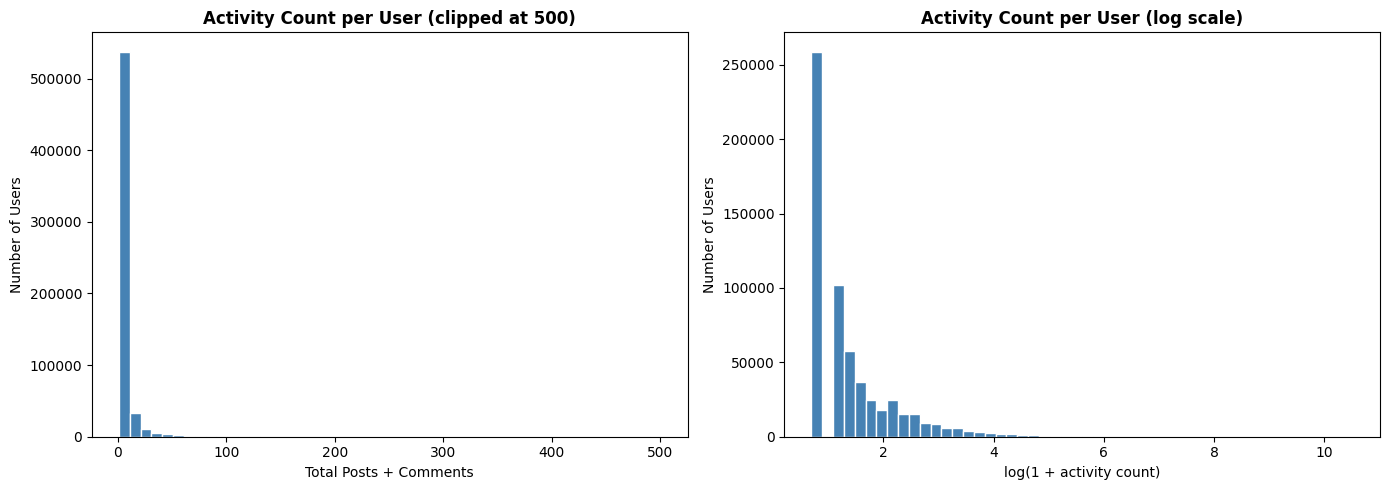

In [48]:
# activity count per user distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_stats['n_activity'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Activity Count per User (clipped at 500)', fontweight='bold')
axes[0].set_xlabel('Total Posts + Comments')
axes[0].set_ylabel('Number of Users')

axes[1].hist(np.log1p(user_stats['n_activity']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Activity Count per User (log scale)', fontweight='bold')
axes[1].set_xlabel('log(1 + activity count)')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

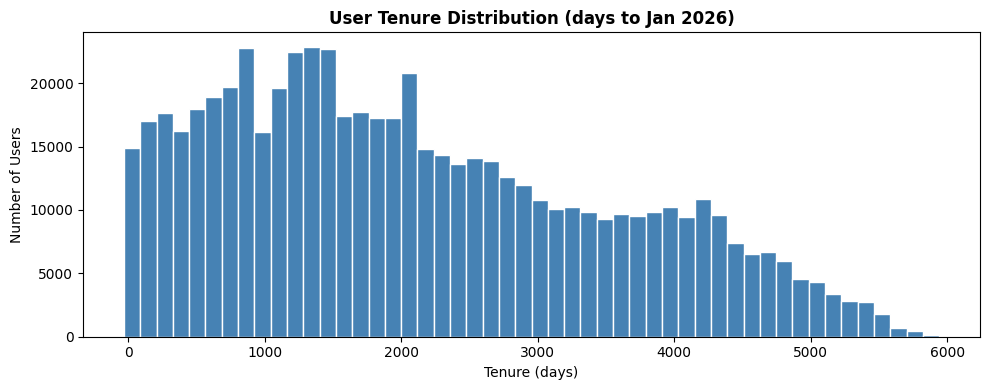

In [49]:
# user tenure distribution
user_stats['tenure_days'] = (OBS_END - user_stats['first_post']).dt.days

plt.figure(figsize=(10, 4))
plt.hist(user_stats['tenure_days'], bins=50, color='steelblue', edgecolor='white')
plt.title('User Tenure Distribution (days to Jan 2026)', fontweight='bold')
plt.xlabel('Tenure (days)')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

In [50]:
# summary stats
user_stats[['n_activity', 'tenure_days']].describe().round(1)

,n_activity,tenure_days
count,601498.0,601498.0
mean,7.5,2117.6
std,102.2,1405.6
min,1.0,-30.0
25%,1.0,971.0
50%,2.0,1877.0
75%,4.0,3141.0
max,37056.0,5942.0


The activity distribution is strongly right-skewed. The median user has only 2 total posts or comments, while the mean is 7.5. A small number of highly active users pull the mean upward considerably, with the most active user contributing 37,056 interactions. This pattern is typical of online communities, where a minority of users account for the majority of content.

User tenure also varies widely. The median tenure is about 1,877 days (roughly 5 years) and the mean is 2,118 days, indicating that r/learnprogramming has accumulated both long-term participants and a large base of occasional visitors over its history.

### Part-4: Community Activity

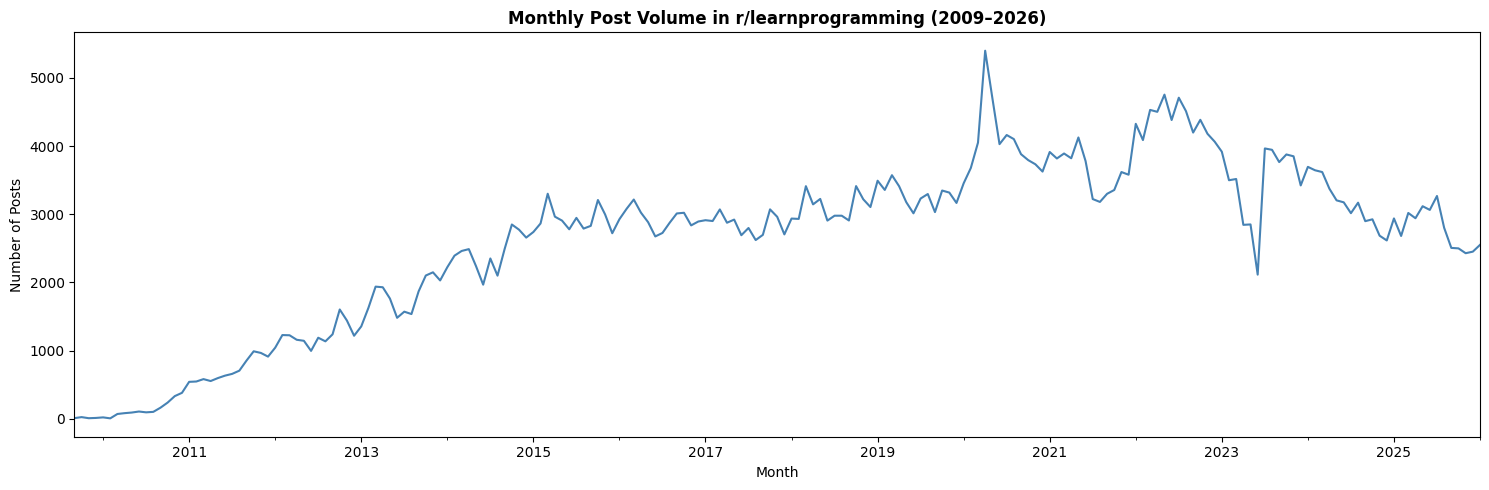

In [51]:
# monthly post volume over time
monthly_posts = posts_df.groupby(posts_df['created_utc'].dt.to_period('M')).size()

plt.figure(figsize=(15, 5))
monthly_posts.plot(color='steelblue', lw=1.5)
plt.title('Monthly Post Volume in r/learnprogramming (2009–2026)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

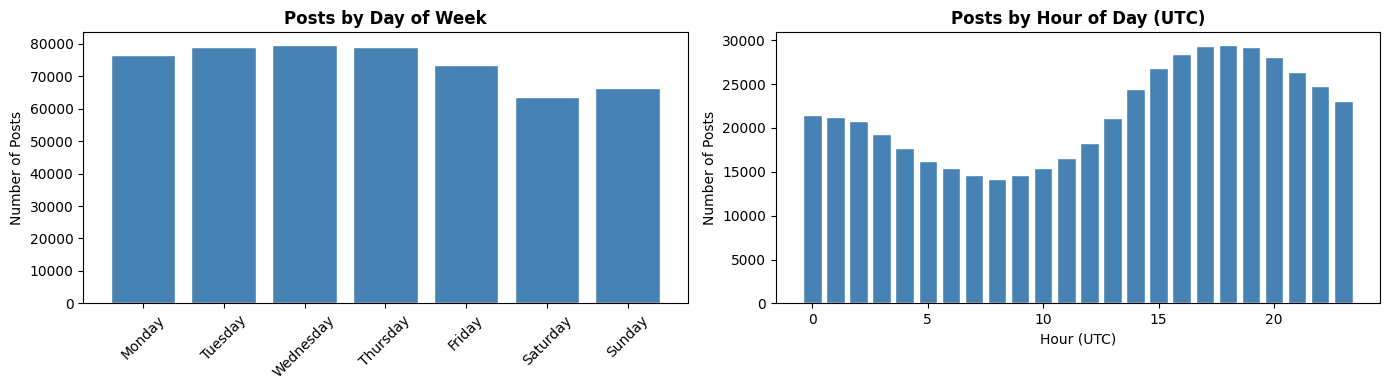

In [52]:
# post volume by day of week and hour of day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily  = posts_df['created_utc'].dt.day_name().value_counts().reindex(day_order)
hourly = posts_df['created_utc'].dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(daily.index, daily.values, color='steelblue', edgecolor='white')
axes[0].set_title('Posts by Day of Week', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[1].set_title('Posts by Hour of Day (UTC)', fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Number of Posts')

plt.tight_layout()
plt.show()

The monthly post volume chart shows that r/learnprogramming experienced sustained growth from its founding in 2009, with activity expanding substantially through the 2010s and reaching consistently high levels in recent years. The day-of-week bar chart shows that weekday posting is more common than weekend posting, which is consistent with the community's focus on learning and skill development tied to school and work schedules. The hourly bar chart (UTC) reveals that activity is concentrated during certain daytime hours, reflecting the geographic distribution of the active user base.

### Part-5: Content Overview

In [53]:
# text posts vs link posts
has_selftext = posts_df['selftext'].notna() & (posts_df['selftext'].str.strip() != '')
print(f'text posts: {has_selftext.sum():,}  ({has_selftext.mean()*100:.1f}%)')
print(f'link posts: {(~has_selftext).sum():,}  ({(~has_selftext).mean()*100:.1f}%)')

text posts: 462,330  (89.4%)
link posts: 54,749  (10.6%)


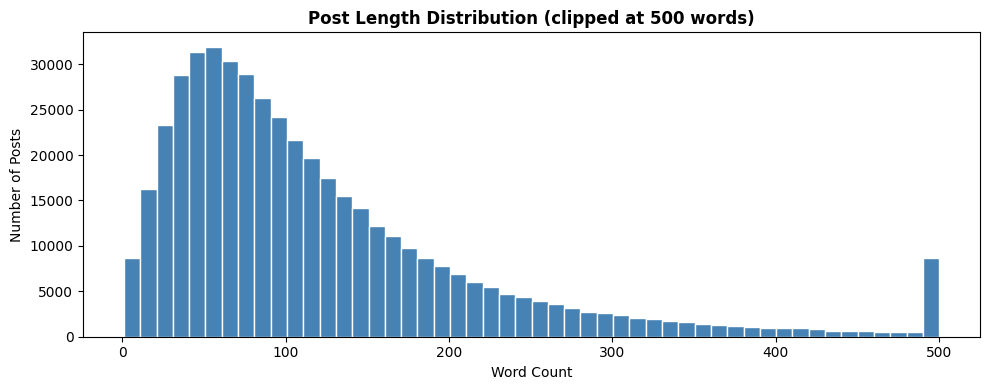

median: 93 words  |  mean: 127 words


In [54]:
# selftext length distribution (text posts only)
text_posts = posts_df[has_selftext].copy()
text_posts['selftext_words'] = text_posts['selftext'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(text_posts['selftext_words'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
plt.title('Post Length Distribution (clipped at 500 words)', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

print(f'median: {text_posts["selftext_words"].median():.0f} words  |  mean: {text_posts["selftext_words"].mean():.0f} words')

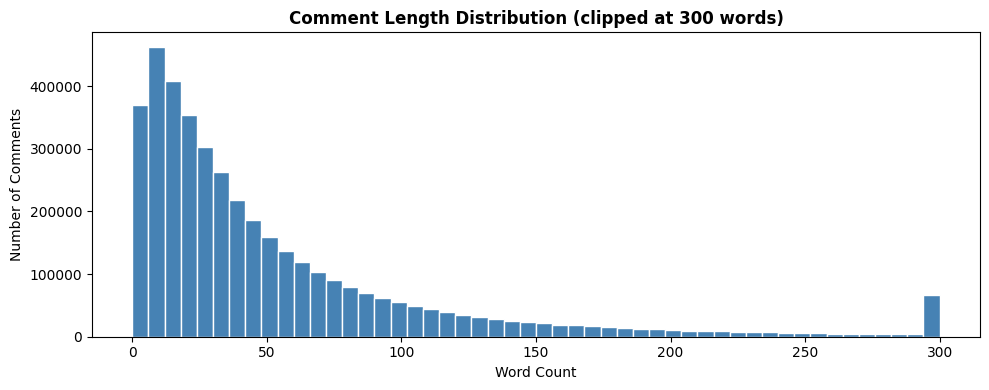

median: 32 words  |  mean: 55 words


In [55]:
# comment body length distribution
valid_comments = comments_df[comments_df['body'].notna()].copy()
valid_comments['body_words'] = valid_comments['body'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(valid_comments['body_words'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
plt.title('Comment Length Distribution (clipped at 300 words)', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

print(f'median: {valid_comments["body_words"].median():.0f} words  |  mean: {valid_comments["body_words"].mean():.0f} words')

The majority of posts in r/learnprogramming are text posts (89.4%), with only 10.6% being link posts. This indicates that users primarily come to the community to ask questions and share written content rather than to link external resources, which is expected for a learning-oriented subreddit.

Among text posts, the median length is 93 words and the mean is 127 words, suggesting that most users write moderately detailed posts when seeking help. Comments are shorter on average, with a median of 32 words and a mean of 55 words. Both distributions are right-skewed, with a small number of posts and comments considerably longer than the typical entry.

### Part-6: BG/NBD Inputs

In [56]:
# compute BG/NBD inputs per qualifying user
bgnbd = user_stats.copy()
bgnbd['T']         = (OBS_END - bgnbd['first_post']).dt.days / 7
bgnbd['recency']   = (bgnbd['last_post'] - bgnbd['first_post']).dt.days / 7
bgnbd['frequency'] = bgnbd['n_activity'] - 1

bgnbd = bgnbd[bgnbd['T'] > 0].reset_index(drop=True)
print(f'users for BG/NBD modeling: {len(bgnbd):,}')
bgnbd[['frequency', 'recency', 'T']].head()

users for BG/NBD modeling: 597,686


,frequency,recency,T
0,6,419.857143,421.857143
1,0,0.000000,342.142857
2,1,0.285714,50.857143
3,0,0.000000,289.571429
4,0,0.000000,250.000000


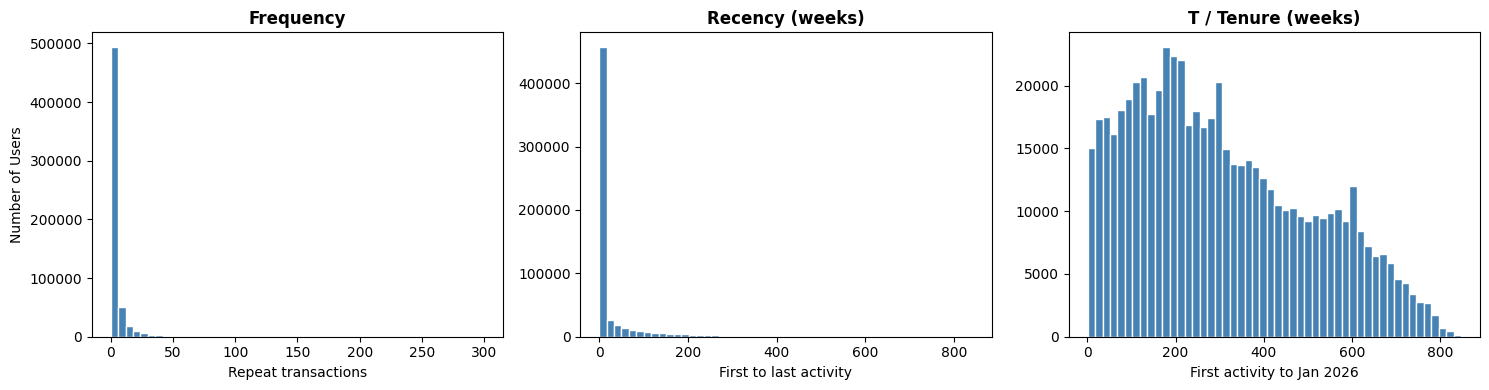

In [57]:
# frequency, recency, T distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(bgnbd['frequency'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Frequency', fontweight='bold')
axes[0].set_xlabel('Repeat transactions')
axes[0].set_ylabel('Number of Users')

axes[1].hist(bgnbd['recency'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Recency (weeks)', fontweight='bold')
axes[1].set_xlabel('First to last activity')

axes[2].hist(bgnbd['T'], bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('T / Tenure (weeks)', fontweight='bold')
axes[2].set_xlabel('First activity to Jan 2026')

plt.tight_layout()
plt.show()

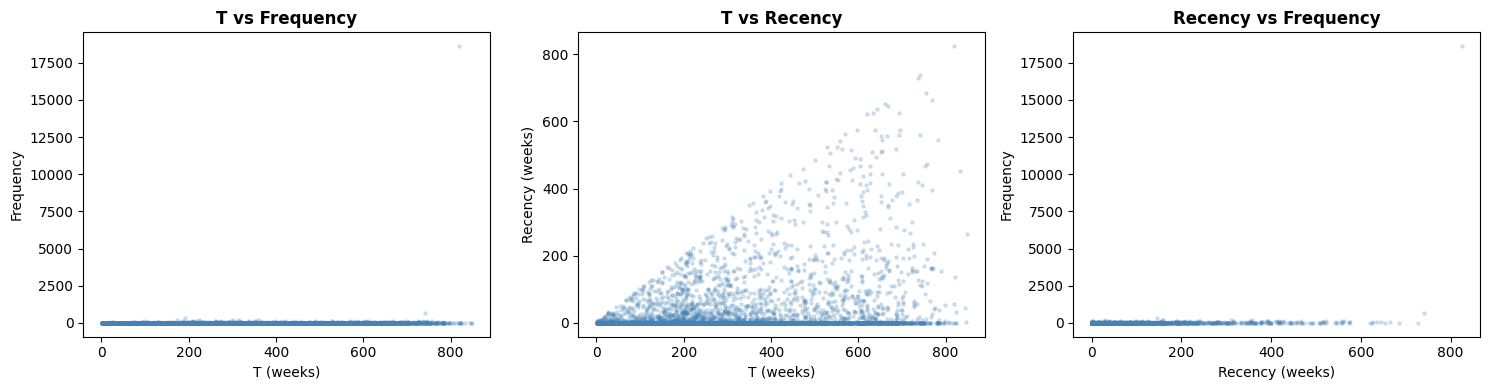

In [58]:
# pairwise scatter plots (sample 5000 users for readability)
sample = bgnbd.sample(min(5000, len(bgnbd)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(sample['T'], sample['frequency'], alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('T (weeks)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('T vs Frequency', fontweight='bold')

axes[1].scatter(sample['T'], sample['recency'], alpha=0.2, s=5, color='steelblue')
axes[1].set_xlabel('T (weeks)')
axes[1].set_ylabel('Recency (weeks)')
axes[1].set_title('T vs Recency', fontweight='bold')

axes[2].scatter(sample['recency'], sample['frequency'], alpha=0.2, s=5, color='steelblue')
axes[2].set_xlabel('Recency (weeks)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Recency vs Frequency', fontweight='bold')

plt.tight_layout()
plt.show()

In [59]:
# summary stats
bgnbd[['frequency', 'recency', 'T']].describe().round(2)

,frequency,recency,T
count,597686.00,597686.00,597686.00
mean,6.57,30.74,304.45
std,102.55,81.47,199.95
min,0.00,0.00,0.14
25%,0.00,0.00,141.29
50%,1.00,0.00,270.00
75%,3.00,12.57,450.43
max,37055.00,842.57,848.86


The three BG/NBD input variables are all strongly right-skewed, which is consistent with what the model expects.

**Frequency** (number of repeat transactions after the first): the median is 1 and the mean is 6.57, indicating that most users have very few return visits. A small number of highly active users extend the tail up to a maximum of 37,055.

**Recency** (weeks from first to last activity): the median recency is 0 weeks, meaning that more than half of users made their first and last activity within the same week (or appeared only once). The mean recency is 30.74 weeks, driven upward by the subset of users who returned over a longer period.

**T** (weeks from first activity to the observation end date of January 2026): the median T is 270 weeks (about 5.2 years) and the mean is 304 weeks. This indicates that a large share of the user base joined the subreddit several years before the observation cutoff.

The scatter plots confirm that recency is always less than or equal to T for every user, which is a required constraint for the BG/NBD model. The T vs. Frequency plot shows that long tenure does not necessarily translate into high frequency, further supporting the view that most users remain low-engagement contributors regardless of how long they have been registered.

### Part-7: Network Preview

In [60]:
# build reply edges from parent_id
# 't1_' prefix means reply to a comment; strip prefix to get parent comment's base id
comment_author = comments_df.set_index('id')['author'].to_dict()

replies = comments_df[comments_df['parent_id'].str.startswith('t1_', na=False)].copy()
replies['parent_comment_id'] = replies['parent_id'].str[3:]
replies['parent_author']     = replies['parent_comment_id'].map(comment_author)

edges_df = replies[['author', 'parent_author']].dropna()
edges_df = edges_df[edges_df['author'] != edges_df['parent_author']]

print(f'total reply edges:             {len(edges_df):,}')
print(f'unique users in reply network: {pd.concat([edges_df["author"], edges_df["parent_author"]]).nunique():,}')

total reply edges:             1,998,645
unique users in reply network: 369,537


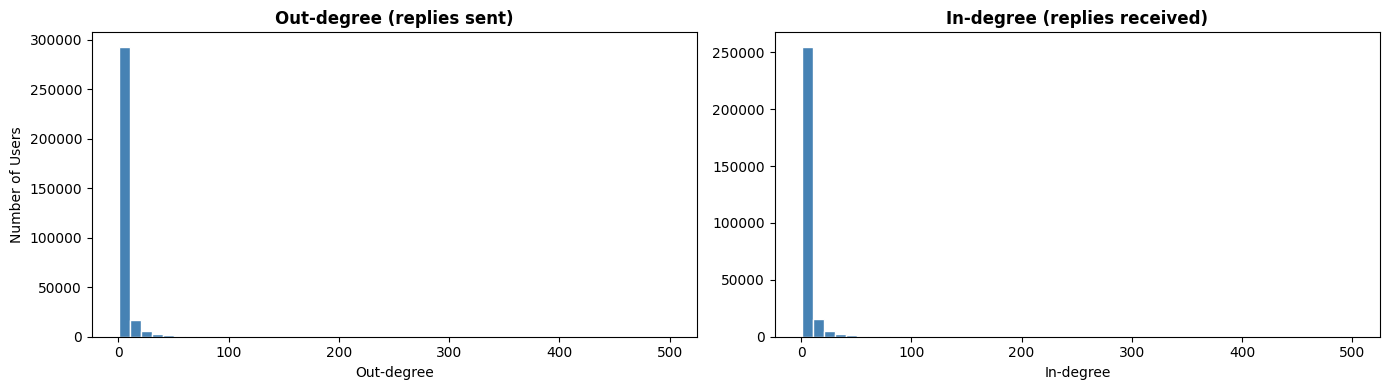

In [61]:
# in-degree and out-degree distributions
out_deg = edges_df['author'].value_counts()
in_deg  = edges_df['parent_author'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(out_deg.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Out-degree (replies sent)', fontweight='bold')
axes[0].set_xlabel('Out-degree')
axes[0].set_ylabel('Number of Users')

axes[1].hist(in_deg.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('In-degree (replies received)', fontweight='bold')
axes[1].set_xlabel('In-degree')

plt.tight_layout()
plt.show()

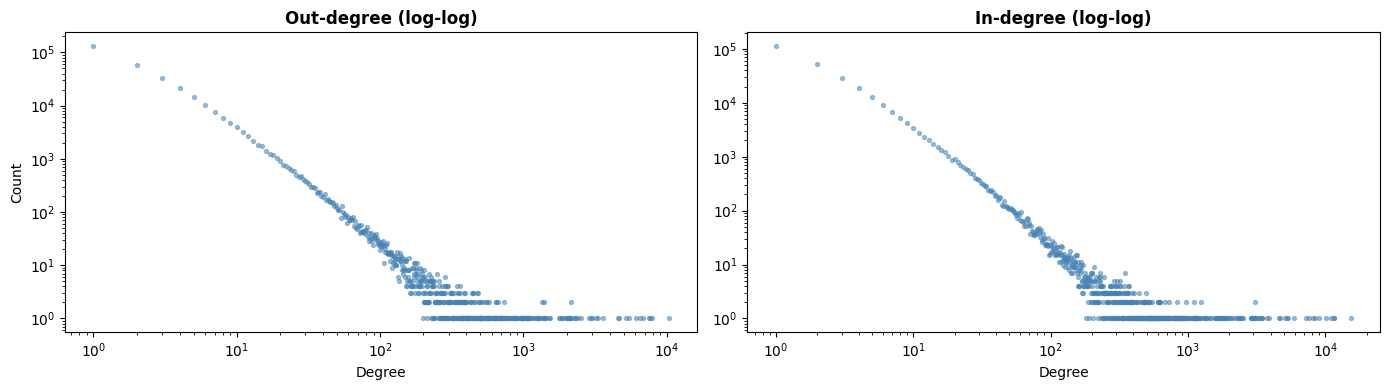

In [62]:
# log-log degree distribution (power-law check)
out_deg_counts = out_deg.value_counts().sort_index()
in_deg_counts  = in_deg.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(out_deg_counts.index, out_deg_counts.values, alpha=0.5, s=8, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Out-degree (log-log)', fontweight='bold')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

axes[1].scatter(in_deg_counts.index, in_deg_counts.values, alpha=0.5, s=8, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('In-degree (log-log)', fontweight='bold')
axes[1].set_xlabel('Degree')

plt.tight_layout()
plt.show()

In [63]:
# basic network stats
all_users = pd.concat([edges_df['author'], edges_df['parent_author']])
print(f'nodes:             {all_users.nunique():,}')
print(f'edges:             {len(edges_df):,}')
print(f'avg out-degree:    {out_deg.mean():.2f}')
print(f'median out-degree: {out_deg.median():.0f}')
print(f'max out-degree:    {out_deg.max():,}')

nodes:             369,537
edges:             1,998,645
avg out-degree:    6.17
median out-degree: 2
max out-degree:    10,276


The reply network contains 1,998,645 directed edges connecting 369,537 unique users. Each edge represents one user directly replying to another user's comment. Out of 601,498 qualifying users, about 61.4% appear in the reply network, meaning a substantial portion of users only posted top-level content without engaging in direct reply exchanges.

The out-degree distribution (replies sent) and in-degree distribution (replies received) are both heavily right-skewed. The average out-degree is 6.17, but the median is only 2, indicating that most users sent very few replies while a small number of users sent a disproportionately large share. The most active replier sent 10,276 replies.

The log-log degree distribution plots show an approximately linear trend for both in-degree and out-degree, which is consistent with a power-law distribution. This is a common structural property of social networks and suggests that the r/learnprogramming reply network has a small number of highly connected "hubs" alongside a large majority of users with minimal connectivity.